<a href="https://colab.research.google.com/github/malikshahzaib263/neurofive-ml-track/blob/main/Week_4_Task_1_ML_Pipeline_and_Feature_Engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 4 – Machine Learning Fundamentals

# Task 1: Build a Proper ML Pipeline with Feature Engineering

### Neurofive Solutions – Machine Learning Track

**Author:** Shahzaib Arshad

---

## Project Overview

This project demonstrates how to build a clean and reusable machine learning pipeline using scikit-learn. The Titanic dataset is used to combine preprocessing and Logistic Regression into a single pipeline.

Numerical features are processed using `StandardScaler`, while categorical features are converted using `OneHotEncoder`. Two additional features, `FamilySize` and `IsAlone`, are engineered and tested to determine whether they improve model performance. Finally, the complete trained pipeline is saved using Joblib.

## Project Objectives

The objectives of this project are:

- Use the previously explored Titanic dataset.
- Build a preprocessing workflow using ColumnTransformer.
- Apply StandardScaler to numerical features.
- Apply OneHotEncoder to categorical features.
- Combine preprocessing and Logistic Regression in a single Pipeline.
- Build and evaluate a baseline pipeline.
- Create at least two engineered features.
- Compare performance before and after feature engineering.
- Save the final trained pipeline using Joblib.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import joblib
import os

print("Libraries imported successfully.")

Libraries imported successfully.


## Load the Dataset

The Titanic training dataset used in the previous tasks is uploaded into Google Colab.

In [2]:
uploaded = files.upload()

Saving train.csv to train.csv


In [3]:
df = pd.read_csv("train.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 891
Columns: 12


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
df.isnull().sum().sort_values(ascending=False)

,0
Cabin,687
Age,177
Embarked,2
PassengerId,0
Name,0
Pclass,0
Survived,0
Sex,0
Parch,0
SibSp,0


## Baseline Feature Selection

The first model is built using the original Titanic features without any newly engineered variables.

The selected features are:

- Pclass
- Sex
- Age
- SibSp
- Parch
- Fare
- Embarked

The target variable is `Survived`.

In [7]:
baseline_features = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked"
]

X_baseline = df[baseline_features].copy()
y = df["Survived"]

print("Features shape:", X_baseline.shape)
print("Target shape:", y.shape)

Features shape: (891, 7)
Target shape: (891,)


In [8]:
baseline_numerical_columns = [
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare"
]

baseline_categorical_columns = [
    "Sex",
    "Embarked"
]

In [9]:
X_train_base, X_test_base, y_train, y_test = train_test_split(
    X_baseline,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train_base.shape)
print("Testing set:", X_test_base.shape)

Training set: (712, 7)
Testing set: (179, 7)


## Numerical Preprocessing

Missing numerical values are filled using the median. After that, StandardScaler standardizes the numerical features so that they are placed on a similar scale.

In [10]:
numerical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

## Categorical Preprocessing

Missing categorical values are filled using the most frequent category. OneHotEncoder then converts text-based categories into numerical features that can be used by the model.

In [11]:
categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            )
        )
    ]
)

## ColumnTransformer

ColumnTransformer allows different preprocessing steps to be applied to different groups of columns. Numerical features are scaled, while categorical features are one-hot encoded.

In [12]:
baseline_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numerical_pipeline,
            baseline_numerical_columns
        ),
        (
            "cat",
            categorical_pipeline,
            baseline_categorical_columns
        )
    ]
)

## Baseline Machine Learning Pipeline

The preprocessing steps and Logistic Regression model are chained into one pipeline. This makes the workflow consistent and reduces the risk of applying preprocessing differently to training and testing data.

In [13]:
baseline_pipeline = Pipeline(
    steps=[
        ("preprocessor", baseline_preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

baseline_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Pclass', 'Age', 'SibSp',
                                                   'Parch', 'Fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['Sex', 'Embarked'])])),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

In [14]:
baseline_pipeline.fit(
    X_train_base,
    y_train
)

print("Baseline pipeline trained successfully.")

Baseline pipeline trained successfully.


In [15]:
baseline_predictions = baseline_pipeline.predict(
    X_test_base
)

In [16]:
baseline_accuracy = accuracy_score(
    y_test,
    baseline_predictions
)

baseline_precision = precision_score(
    y_test,
    baseline_predictions
)

baseline_recall = recall_score(
    y_test,
    baseline_predictions
)

baseline_f1 = f1_score(
    y_test,
    baseline_predictions
)

print(f"Accuracy:  {baseline_accuracy:.4f}")
print(f"Precision: {baseline_precision:.4f}")
print(f"Recall:    {baseline_recall:.4f}")
print(f"F1-score:  {baseline_f1:.4f}")

Accuracy:  0.8045
Precision: 0.7931
Recall:    0.6667
F1-score:  0.7244


In [17]:
print(
    classification_report(
        y_test,
        baseline_predictions,
        target_names=[
            "Did Not Survive",
            "Survived"
        ]
    )
)

                 precision    recall  f1-score   support

Did Not Survive       0.81      0.89      0.85       110
       Survived       0.79      0.67      0.72        69

       accuracy                           0.80       179
      macro avg       0.80      0.78      0.79       179
   weighted avg       0.80      0.80      0.80       179



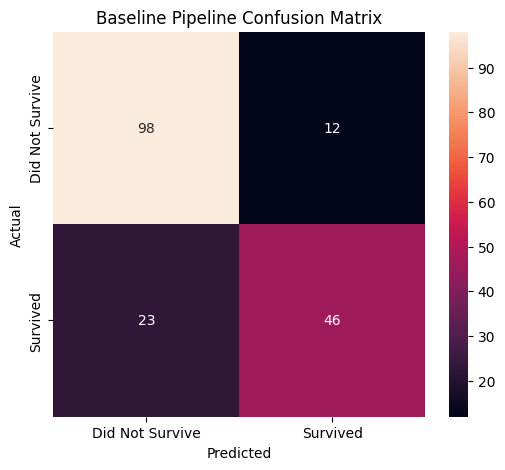

In [18]:
baseline_cm = confusion_matrix(
    y_test,
    baseline_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    baseline_cm,
    annot=True,
    fmt="d",
    xticklabels=["Did Not Survive", "Survived"],
    yticklabels=["Did Not Survive", "Survived"]
)

plt.title("Baseline Pipeline Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Feature Engineering

Feature engineering creates new variables from existing data that may help the model identify useful patterns.

Two new features are created:

### FamilySize

`FamilySize = SibSp + Parch + 1`

This represents the total number of people in the passenger's family group, including the passenger.

### IsAlone

`IsAlone = 1` if FamilySize is equal to 1, otherwise `0`.

This feature indicates whether the passenger was travelling alone.

In [19]:
df_engineered = df.copy()

df_engineered["FamilySize"] = (
    df_engineered["SibSp"]
    + df_engineered["Parch"]
    + 1
)

df_engineered["IsAlone"] = (
    df_engineered["FamilySize"] == 1
).astype(int)

df_engineered[
    [
        "SibSp",
        "Parch",
        "FamilySize",
        "IsAlone"
    ]
].head(10)

,SibSp,Parch,FamilySize,IsAlone
0,1,0,2,0
1,1,0,2,0
2,0,0,1,1
3,1,0,2,0
4,0,0,1,1
5,0,0,1,1
6,0,0,1,1
7,3,1,5,0
8,0,2,3,0
9,1,0,2,0


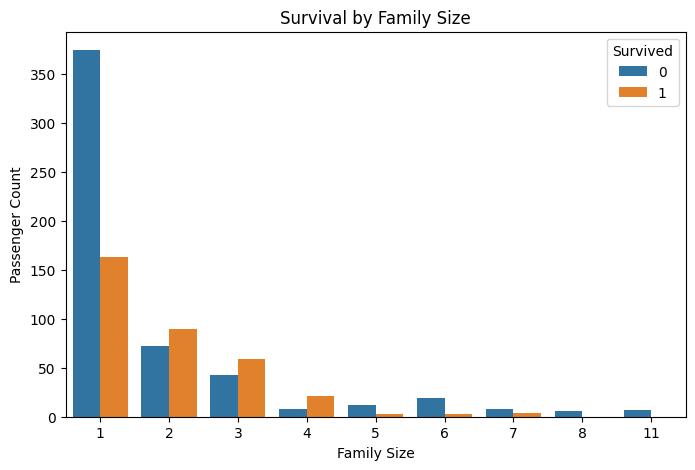

In [20]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_engineered,
    x="FamilySize",
    hue="Survived"
)

plt.title("Survival by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Passenger Count")
plt.show()

In [21]:
engineered_features = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked",
    "FamilySize",
    "IsAlone"
]

X_engineered = df_engineered[
    engineered_features
].copy()

In [22]:
engineered_numerical_columns = [
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "FamilySize",
    "IsAlone"
]

engineered_categorical_columns = [
    "Sex",
    "Embarked"
]

In [23]:
X_train_eng, X_test_eng, y_train_eng, y_test_eng = train_test_split(
    X_engineered,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [24]:
engineered_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numerical_pipeline,
            engineered_numerical_columns
        ),
        (
            "cat",
            categorical_pipeline,
            engineered_categorical_columns
        )
    ]
)

## Final Pipeline with Feature Engineering

The final model uses the same preprocessing workflow but also includes the two engineered features, FamilySize and IsAlone.

In [25]:
final_pipeline = Pipeline(
    steps=[
        ("preprocessor", engineered_preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

final_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Pclass', 'Age', 'SibSp',
                                                   'Parch', 'Fare',
                                                   'FamilySize', 'IsAlone']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['Sex', 'Embarked'])])),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

In [26]:
final_pipeline.fit(
    X_train_eng,
    y_train_eng
)

print("Final pipeline trained successfully.")

Final pipeline trained successfully.


In [27]:
final_predictions = final_pipeline.predict(
    X_test_eng
)

In [28]:
final_accuracy = accuracy_score(
    y_test_eng,
    final_predictions
)

final_precision = precision_score(
    y_test_eng,
    final_predictions
)

final_recall = recall_score(
    y_test_eng,
    final_predictions
)

final_f1 = f1_score(
    y_test_eng,
    final_predictions
)

print(f"Accuracy:  {final_accuracy:.4f}")
print(f"Precision: {final_precision:.4f}")
print(f"Recall:    {final_recall:.4f}")
print(f"F1-score:  {final_f1:.4f}")

Accuracy:  0.8045
Precision: 0.7833
Recall:    0.6812
F1-score:  0.7287


## Baseline vs Feature-Engineered Pipeline

The baseline pipeline is compared with the final pipeline to determine whether FamilySize and IsAlone improve model performance.

In [29]:
comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],
    "Baseline Pipeline": [
        baseline_accuracy,
        baseline_precision,
        baseline_recall,
        baseline_f1
    ],
    "Feature-Engineered Pipeline": [
        final_accuracy,
        final_precision,
        final_recall,
        final_f1
    ]
})

comparison[
    [
        "Baseline Pipeline",
        "Feature-Engineered Pipeline"
    ]
] = comparison[
    [
        "Baseline Pipeline",
        "Feature-Engineered Pipeline"
    ]
].round(4)

comparison

,Metric,Baseline Pipeline,Feature-Engineered Pipeline
0,Accuracy,0.8045,0.8045
1,Precision,0.7931,0.7833
2,Recall,0.6667,0.6812
3,F1-score,0.7244,0.7287


In [30]:
accuracy_change = final_accuracy - baseline_accuracy
f1_change = final_f1 - baseline_f1

print(f"Accuracy change: {accuracy_change:+.4f}")
print(f"F1-score change: {f1_change:+.4f}")

Accuracy change: +0.0000
F1-score change: +0.0043


In [31]:
if final_accuracy > baseline_accuracy:
    print("Feature engineering improved accuracy.")
elif final_accuracy < baseline_accuracy:
    print("Feature engineering slightly reduced accuracy.")
else:
    print("Accuracy remained unchanged.")

if final_f1 > baseline_f1:
    print("Feature engineering improved F1-score.")
elif final_f1 < baseline_f1:
    print("Feature engineering slightly reduced F1-score.")
else:
    print("F1-score remained unchanged.")

Accuracy remained unchanged.
Feature engineering improved F1-score.


In [32]:
os.makedirs(
    "Week_4/models",
    exist_ok=True
)

print("Folder created successfully.")

Folder created successfully.


In [33]:
model_path = "Week_4/models/titanic_final_pipeline.joblib"

joblib.dump(
    final_pipeline,
    model_path
)

print("Pipeline saved at:")
print(model_path)

Pipeline saved at:
Week_4/models/titanic_final_pipeline.joblib


In [34]:
print(
    "File exists:",
    os.path.exists(model_path)
)

print(
    "File size:",
    os.path.getsize(model_path),
    "bytes"
)

File exists: True
File size: 5098 bytes


In [35]:
loaded_pipeline = joblib.load(
    model_path
)

print("Pipeline loaded successfully.")

Pipeline loaded successfully.


In [36]:
loaded_predictions = loaded_pipeline.predict(
    X_test_eng
)

print(
    "Predictions identical:",
    np.array_equal(
        final_predictions,
        loaded_predictions
    )
)

Predictions identical: True


In [37]:
files.download(model_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Conclusion

In this project, I created a complete machine learning workflow using scikit-learn Pipeline and ColumnTransformer. Numerical features were imputed and standardized using StandardScaler, while categorical variables were processed using OneHotEncoder.

The preprocessing and Logistic Regression model were combined into a single reusable pipeline. Two additional features, FamilySize and IsAlone, were engineered and tested against the baseline model. Their effect was evaluated using Accuracy, Precision, Recall, and F1-score.

Finally, the complete trained pipeline was saved using Joblib and successfully reloaded to verify that it produced identical predictions. This demonstrates how pipelines improve consistency, reproducibility, and maintainability in machine learning projects.